# 🚢 Titanic Survival Analysis — EDA & Machine Learning Project

## 📌 Project Overview
This project explores the Titanic dataset using Exploratory Data Analysis (EDA) and builds a Machine Learning model to predict passenger survival.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Style
sns.set_theme(style='darkgrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 5)

print('Libraries loaded ✅')

Libraries loaded ✅


## 1️⃣ Load Data

In [2]:
df = pd.read_csv('titanic.csv')

print(f'Shape: {df.shape}')
df.head()

Shape: (891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## 2️⃣ Data Overview & Missing Values

In [3]:
print('=== Dataset Info ===')
print(df.info())
print('\n=== Missing Values ===')
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
print(missing_df[missing_df['Missing Count'] > 0])

=== Dataset Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB
None

=== Missing Values ===
          Missing Count  Missing %
Age                 177      19.87
Cabin               687      77.10
Embarked              2       0.22


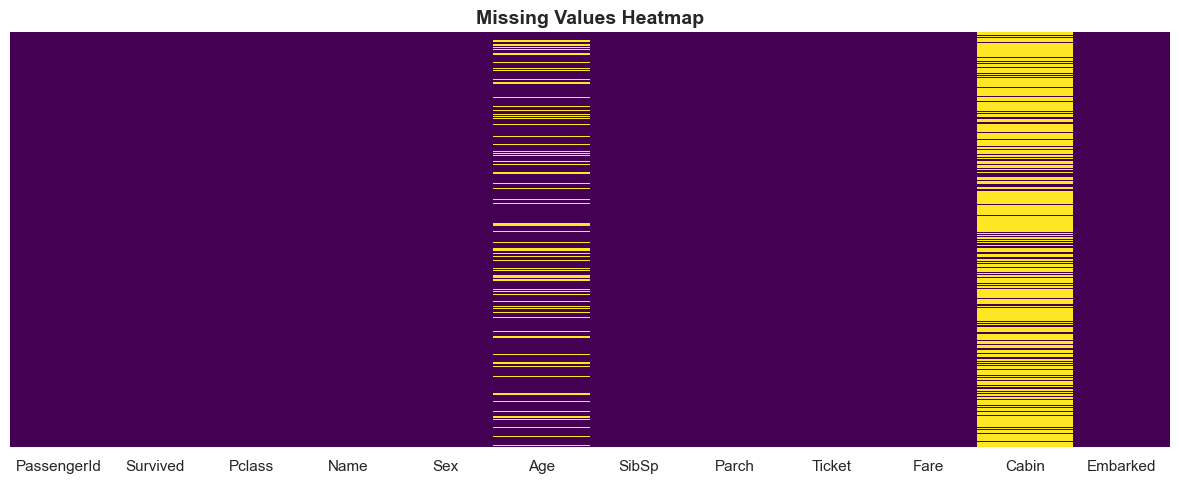

In [4]:
# Missing values heatmap
plt.figure(figsize=(12, 5))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis', yticklabels=False)
plt.title('Missing Values Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 3️⃣ Data Cleaning

In [5]:
df_clean = df.copy()

# Age: 
df_clean['Age'] = df_clean.groupby('Pclass')['Age'].transform(lambda x: x.fillna(x.median()))

# Embarked:
df_clean['Embarked'] = df_clean['Embarked'].fillna(df_clean['Embarked'].mode()[0])

# Cabin: 
df_clean.drop(columns=['Cabin'], inplace=True)

# New features
df_clean['FamilySize'] = df_clean['SibSp'] + df_clean['Parch'] + 1
df_clean['IsAlone'] = (df_clean['FamilySize'] == 1).astype(int)
df_clean['Title'] = df_clean['Name'].str.extract(r' ([A-Za-z]+)\.', expand=False)
df_clean['Title'] = df_clean['Title'].replace(['Lady','Countess','Capt','Col','Don','Dr','Major','Rev','Sir','Jonkheer','Dona'], 'Rare')
df_clean['Title'] = df_clean['Title'].replace({'Mlle':'Miss', 'Ms':'Miss', 'Mme':'Mrs'})

print('Cleaning done ✅')
print(f'Remaining missing:\n{df_clean.isnull().sum()[df_clean.isnull().sum()>0]}')
df_clean.head()

Cleaning done ✅
Remaining missing:
Series([], dtype: int64)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,FamilySize,IsAlone,Title
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S,2,0,Mr
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C,2,0,Mrs
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S,1,1,Miss
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S,2,0,Mrs
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S,1,1,Mr


## 4️⃣ Univariate Analysis

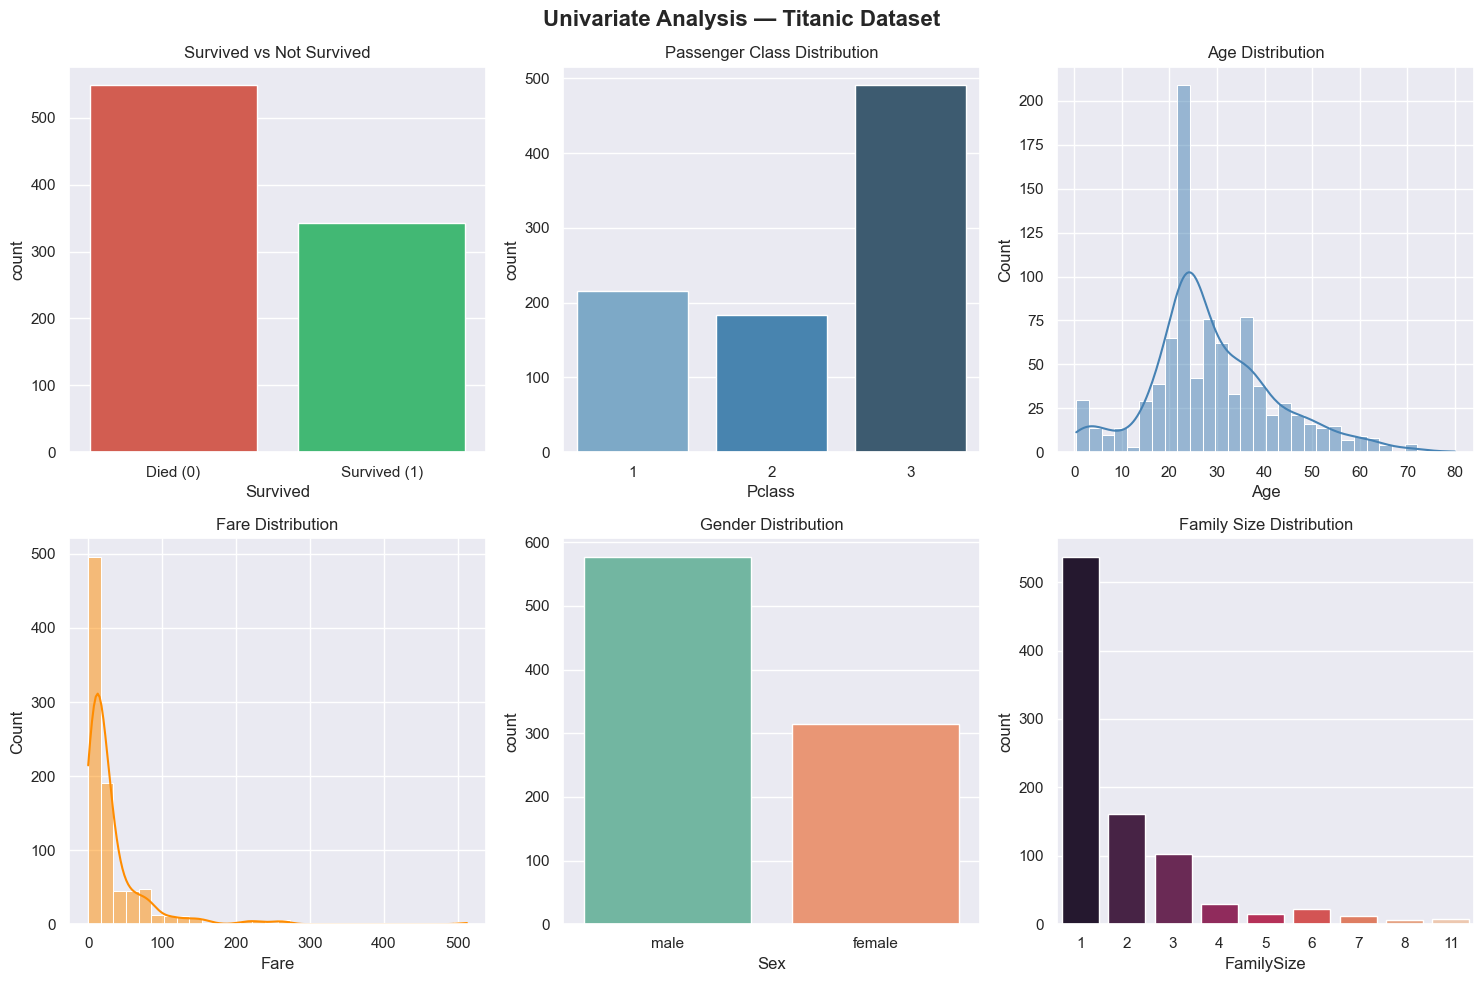

In [6]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# Survival count
sns.countplot(data=df_clean, x='Survived', ax=axes[0,0], palette=['#e74c3c','#2ecc71'])
axes[0,0].set_title('Survived vs Not Survived')
axes[0,0].set_xticklabels(['Died (0)', 'Survived (1)'])

# Passenger Class
sns.countplot(data=df_clean, x='Pclass', ax=axes[0,1], palette='Blues_d')
axes[0,1].set_title('Passenger Class Distribution')

# Age Distribution
sns.histplot(data=df_clean, x='Age', bins=30, kde=True, ax=axes[0,2], color='steelblue')
axes[0,2].set_title('Age Distribution')

# Fare Distribution
sns.histplot(data=df_clean, x='Fare', bins=30, kde=True, ax=axes[1,0], color='darkorange')
axes[1,0].set_title('Fare Distribution')

# Sex
sns.countplot(data=df_clean, x='Sex', ax=axes[1,1], palette='Set2')
axes[1,1].set_title('Gender Distribution')

# FamilySize
sns.countplot(data=df_clean, x='FamilySize', ax=axes[1,2], palette='rocket')
axes[1,2].set_title('Family Size Distribution')

plt.suptitle('Univariate Analysis — Titanic Dataset', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

## 5️⃣ Bivariate Analysis — Survival vs Features

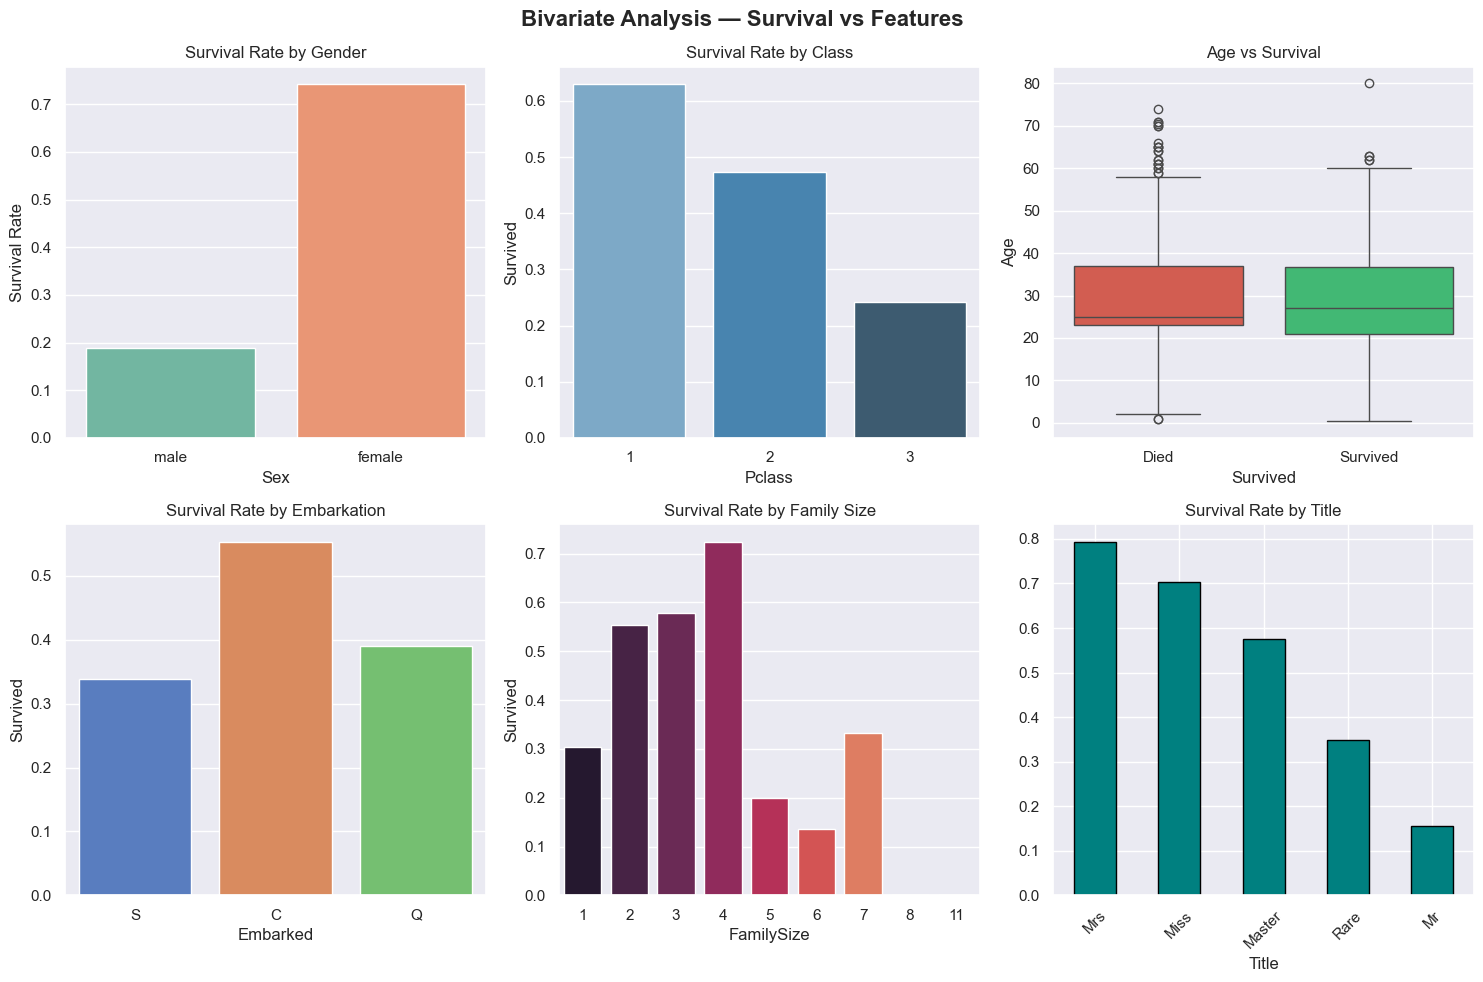

In [7]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# Survival by Sex
sns.barplot(data=df_clean, x='Sex', y='Survived', ax=axes[0,0], palette='Set2', ci=None)
axes[0,0].set_title('Survival Rate by Gender')
axes[0,0].set_ylabel('Survival Rate')

# Survival by Pclass
sns.barplot(data=df_clean, x='Pclass', y='Survived', ax=axes[0,1], palette='Blues_d', ci=None)
axes[0,1].set_title('Survival Rate by Class')

# Survival by Age (boxplot)
sns.boxplot(data=df_clean, x='Survived', y='Age', ax=axes[0,2], palette=['#e74c3c','#2ecc71'])
axes[0,2].set_title('Age vs Survival')
axes[0,2].set_xticklabels(['Died', 'Survived'])

# Survival by Embarked
sns.barplot(data=df_clean, x='Embarked', y='Survived', ax=axes[1,0], palette='muted', ci=None)
axes[1,0].set_title('Survival Rate by Embarkation')

# Survival by FamilySize
sns.barplot(data=df_clean, x='FamilySize', y='Survived', ax=axes[1,1], palette='rocket', ci=None)
axes[1,1].set_title('Survival Rate by Family Size')

# Survival by Title
title_survival = df_clean.groupby('Title')['Survived'].mean().sort_values(ascending=False)
title_survival.plot(kind='bar', ax=axes[1,2], color='teal', edgecolor='black')
axes[1,2].set_title('Survival Rate by Title')
axes[1,2].tick_params(axis='x', rotation=45)

plt.suptitle('Bivariate Analysis — Survival vs Features', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

## 6️⃣ Multivariate Analysis

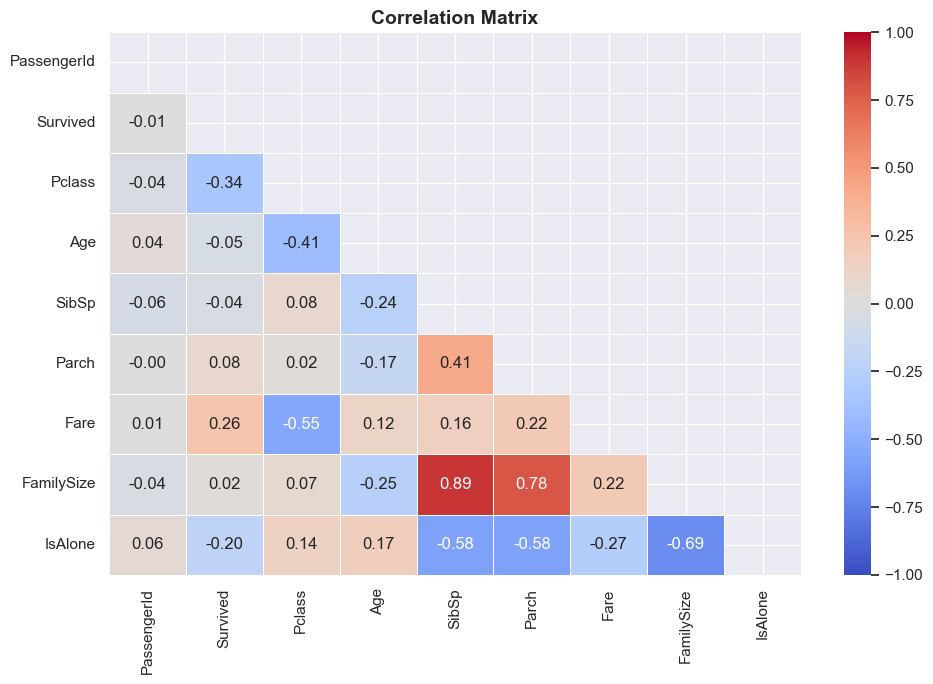

In [8]:
# Heatmap — Correlation Matrix
numeric_cols = df_clean.select_dtypes(include=np.number).columns.tolist()
corr = df_clean[numeric_cols].corr()

plt.figure(figsize=(10, 7))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, vmin=-1, vmax=1)
plt.title('Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

<Figure size 1000x500 with 0 Axes>

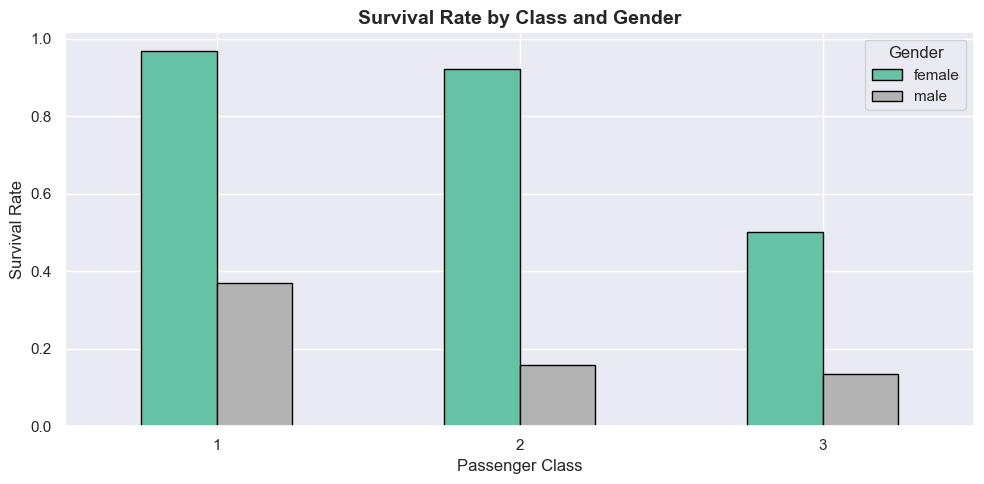

In [9]:
# Pclass + Sex + Survival
plt.figure(figsize=(10, 5))
survival_pivot = df_clean.groupby(['Pclass', 'Sex'])['Survived'].mean().unstack()
survival_pivot.plot(kind='bar', colormap='Set2', edgecolor='black')
plt.title('Survival Rate by Class and Gender', fontsize=14, fontweight='bold')
plt.ylabel('Survival Rate')
plt.xlabel('Passenger Class')
plt.xticks(rotation=0)
plt.legend(title='Gender')
plt.tight_layout()
plt.show()

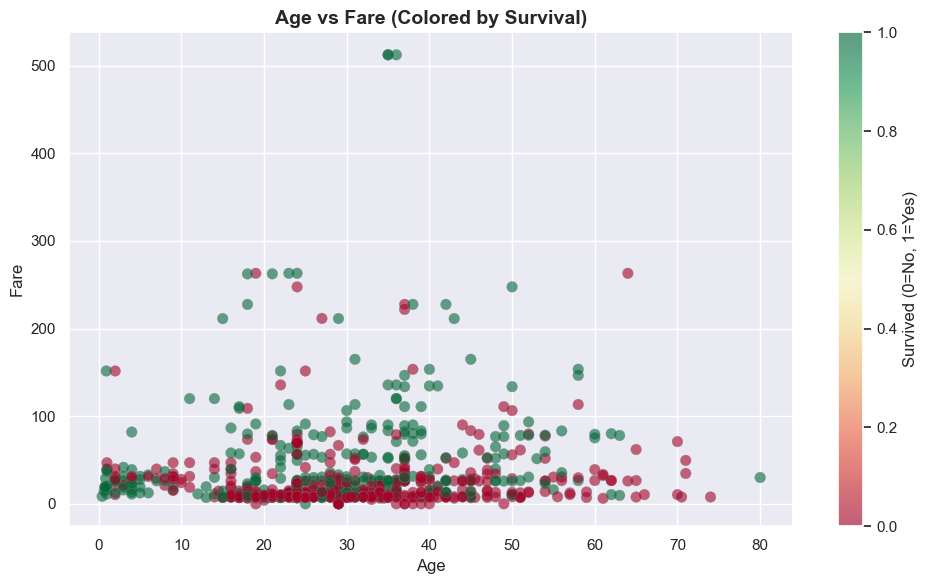

In [10]:
# Age vs Fare scatterplot with Survival color
plt.figure(figsize=(10, 6))
scatter = plt.scatter(
    df_clean['Age'], df_clean['Fare'],
    c=df_clean['Survived'], cmap='RdYlGn',
    alpha=0.6, edgecolors='gray', linewidth=0.3, s=60
)
plt.colorbar(scatter, label='Survived (0=No, 1=Yes)')
plt.title('Age vs Fare (Colored by Survival)', fontsize=14, fontweight='bold')
plt.xlabel('Age')
plt.ylabel('Fare')
plt.tight_layout()
plt.show()

## 7️⃣ Machine Learning Model

Accuracy: 0.8324022346368715

Classification Report:
               precision    recall  f1-score   support

           0       0.86      0.86      0.86       105
           1       0.80      0.80      0.80        74

    accuracy                           0.83       179
   macro avg       0.83      0.83      0.83       179
weighted avg       0.83      0.83      0.83       179


Confusion Matrix:
 [[90 15]
 [15 59]]


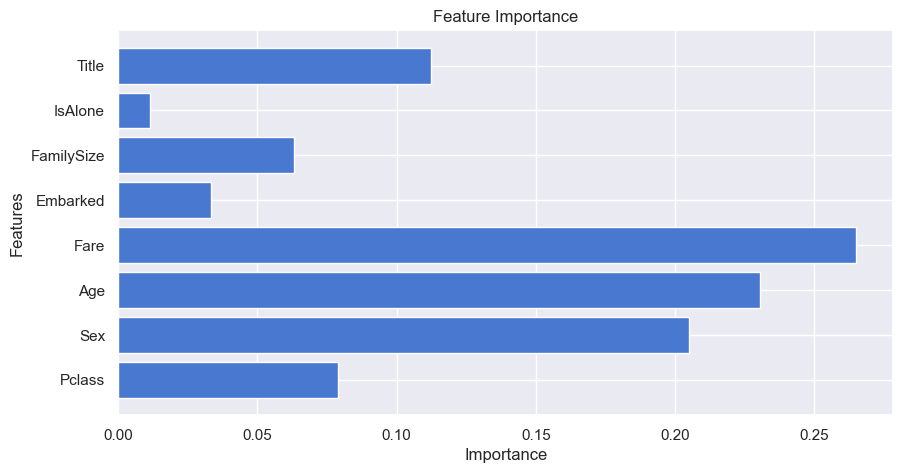

In [11]:
# ===============================
# 1️⃣ Import Libraries
# ===============================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# ===============================
# 2️⃣ Load Dataset
# ===============================
df = pd.read_csv("titanic.csv")

# ===============================
# 3️⃣ Data Cleaning & Feature Engineering
# ===============================

df_clean = df.copy()

# Fill missing values
df_clean['Age'] = df_clean['Age'].fillna(df_clean['Age'].median())
df_clean['Embarked'] = df_clean['Embarked'].fillna(df_clean['Embarked'].mode()[0])
# ===============================
# Create New Features
# ===============================

# Family Size
df_clean['FamilySize'] = df_clean['SibSp'] + df_clean['Parch'] + 1

# IsAlone
df_clean['IsAlone'] = 0
df_clean.loc[df_clean['FamilySize'] == 1, 'IsAlone'] = 1

# Title (from Name)
df_clean['Title'] = df_clean['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)

# ===============================
# Encoding Categorical Data
# ===============================
le = LabelEncoder()

df_clean['Sex'] = le.fit_transform(df_clean['Sex'])
df_clean['Embarked'] = le.fit_transform(df_clean['Embarked'])
df_clean['Title'] = le.fit_transform(df_clean['Title'])

# ===============================
# 4️⃣ Feature Selection
# ===============================
features = ['Pclass', 'Sex', 'Age', 'Fare', 'Embarked', 
            'FamilySize', 'IsAlone', 'Title']

X = df_clean[features]
y = df_clean['Survived']

# ===============================
# 5️⃣ Train-Test Split
# ===============================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ===============================
# 6️⃣ Model Training
# ===============================
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

# ===============================
# 7️⃣ Prediction
# ===============================
y_pred = model.predict(X_test)

# ===============================
# 8️⃣ Evaluation
# ===============================
print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nClassification Report:\n", classification_report(y_test, y_pred))

print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

# ===============================
# 9️⃣ Feature Importance
# ===============================
importances = model.feature_importances_

plt.figure()
plt.barh(features, importances)
plt.xlabel("Importance")
plt.ylabel("Features")
plt.title("Feature Importance")
plt.show()

## 8️⃣ 📊 Feature Importance & Insights

### 📊 Key Findings 
Females had significantly higher survival (~74%) compared to males (~19%)
Passengers in 1st class had much higher survival than 3rd class
Children had better survival chances
Medium family sizes (2–4) showed optimal survival patterns
Higher fare correlated with higher survival probability
### 📊 Understanding Feature Importance

Feature importance helps identify which variables have the most influence on the model’s predictions.

In this project, we use a Random Forest model to evaluate the importance of each feature in predicting passenger survival.

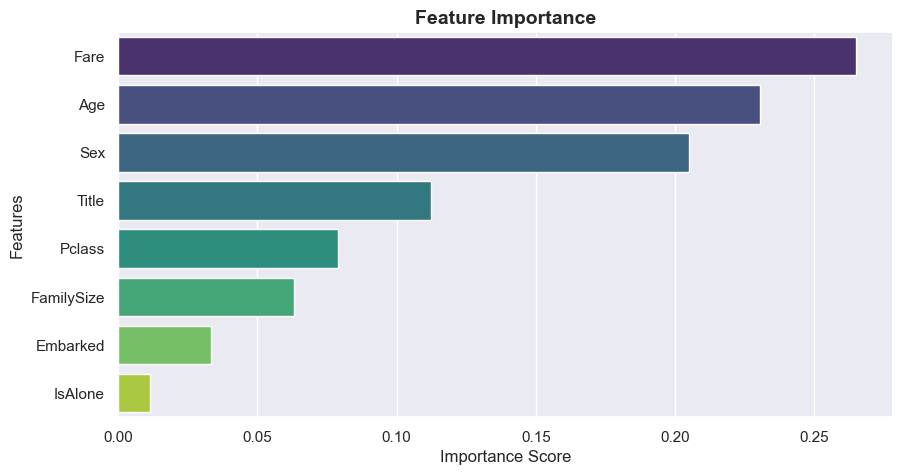

In [12]:
importance = pd.Series(model.feature_importances_, index=X.columns)
importance = importance.sort_values(ascending=False)

plt.figure(figsize=(10,5))
sns.barplot(x=importance.values, y=importance.index, palette='viridis')
plt.title("Feature Importance", fontsize=14, fontweight='bold')
plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.show()

### 🔍 Key Observations

- Gender (Sex) is the most influential feature in predicting survival
- Passenger class (Pclass) and Fare also significantly impact survival chances
- Title extracted from names improves model performance
- Age and FamilySize have moderate importance

👉 These findings align with our EDA insights, confirming that women and higher-class passengers had better survival rates.